# Plant Whisper AI — MobileNetV2 with Manual Class Weights


In [14]:
import os
import shutil
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Train/Test split with grouping to avoid augmentation leakage

In [16]:
SOURCE_DIR = "/content/drive/MyDrive/AgriNova/processed_dataset_augmented"  # UNBALANCED source — let class_weight handle the imbalance instead of synthetic balancing
OUT_DIR = "/content/dataset_split"  # local Colab disk — Drive can be read-only/slow for many small file copies
CLASSES = ["Cut", "Dry"]
TEST_SIZE = 0.2
SEED = 42

def get_group_id(filename):
    # Strips _augN / _vN suffixes so all variants of one source recording
    # land in the same split (train OR test, never both).
    return re.sub(r'(_aug\d+|_v\d+)?\.\w+$', '', filename)

# Only rebuild the split if it doesn't already exist, so re-running the
# notebook doesn't reshuffle files that are already split.
if not os.path.exists(OUT_DIR):
    for cls in CLASSES:
        files = os.listdir(os.path.join(SOURCE_DIR, cls))
        groups = sorted(set(get_group_id(f) for f in files))

        train_groups, test_groups = train_test_split(
            groups, test_size=TEST_SIZE, random_state=SEED
        )

        for split_name, split_groups in [("train", train_groups), ("test", test_groups)]:
            out_path = os.path.join(OUT_DIR, split_name, cls)
            os.makedirs(out_path, exist_ok=True)
            for f in files:
                if get_group_id(f) in split_groups:
                    shutil.copy(
                        os.path.join(SOURCE_DIR, cls, f),
                        os.path.join(out_path, f)
                    )

        print(f"{cls}: {len(train_groups)} train groups, {len(test_groups)} test groups")
else:
    print(f"{OUT_DIR} already exists — skipping split (delete it first to rebuild).")

/content/dataset_split already exists — skipping split (delete it first to rebuild).


## 2. Data generators

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.05,
    zoom_range=0.05
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(OUT_DIR, "train"),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(OUT_DIR, "test"),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # keep order aligned with .classes for evaluation later
)

print("Class indices:", train_generator.class_indices)

Found 9112 images belonging to 2 classes.
Found 2278 images belonging to 2 classes.
Class indices: {'Cut': 0, 'Dry': 1}


## 3. Manual class weights — lighter correction than auto 'balanced' (1.73/0.70)

In [18]:
# NOTE: this assumes Cut=0, Dry=1 per the class_indices above.
# If it's reversed, swap which key gets 1.3 vs 0.85.
class_weight_dict = {0: 1.3, 1: 0.85}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.3, 1: 0.85}


## 4. Build model — MobileNetV2, frozen base

In [19]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',  # default LR = 1e-3
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

## 5. Phase 1 — train classifier head only

In [20]:
print("--- Phase 1: Training classifier head (base frozen) ---")
print("Base trainable:", base_model.trainable)
print("Optimizer LR:", model.optimizer.learning_rate.numpy())

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

--- Phase 1: Training classifier head (base frozen) ---
Base trainable: False
Optimizer LR: 0.001
Epoch 1/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 77s 240ms/step - accuracy: 0.6843 - loss: 0.6458 - val_accuracy: 0.7344 - val_loss: 0.5874 - learning_rate: 0.0010
Epoch 2/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.7162 - loss: 0.6120 - val_accuracy: 0.7406 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 3/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 192ms/step - accuracy: 0.7207 - loss: 0.5960 - val_accuracy: 0.7208 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 4/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 83s 197ms/step - accuracy: 0.7216 - loss: 0.5960 - val_accuracy: 0.6993 - val_loss: 0.5839 - learning_rate: 0.0010
Epoch 5/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 78s 185ms/step - accuracy: 0.7284 - loss: 0.5872 - val_accuracy: 0.7243 - val_loss: 0.5512 - learning_rate: 5.0000e-04
Epoch 6/40
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 193ms/step - accuracy: 0.7306 - loss: 0.5841 - val_accuracy: 0.7327 - val_loss:

In [21]:
model.save("/content/drive/MyDrive/manual_weights_phase1%.keras")
print("Saved manual_weights_phase1.keras to Drive")

Saved manual_weights_phase1.keras to Drive


## 6. Phase 2 — fine-tune top layers (BatchNorm kept frozen)

In [22]:
print("--- Phase 2: Fine-tuning top layers ---")
base_model.trainable = True

# Unfreeze only the last 15 layers — keep the rest frozen
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Critical fix: keep ALL BatchNorm layers frozen even in the unfrozen region,
# otherwise their running stats destabilize on a small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

--- Phase 2: Fine-tuning top layers ---
Epoch 1/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 78s 239ms/step - accuracy: 0.7400 - loss: 0.5663 - val_accuracy: 0.7458 - val_loss: 0.5289 - learning_rate: 5.0000e-06
Epoch 2/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 193ms/step - accuracy: 0.7426 - loss: 0.5622 - val_accuracy: 0.7480 - val_loss: 0.5278 - learning_rate: 5.0000e-06
Epoch 3/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 54s 190ms/step - accuracy: 0.7420 - loss: 0.5589 - val_accuracy: 0.6923 - val_loss: 0.5772 - learning_rate: 5.0000e-06
Epoch 4/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 53s 188ms/step - accuracy: 0.7474 - loss: 0.5637 - val_accuracy: 0.7410 - val_loss: 0.5275 - learning_rate: 5.0000e-06
Epoch 5/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 56s 195ms/step - accuracy: 0.7437 - loss: 0.5558 - val_accuracy: 0.7542 - val_loss: 0.5147 - learning_rate: 5.0000e-06
Epoch 6/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 55s 192ms/step - accuracy: 0.7493 - loss: 0.5552 - val_accuracy: 0.6488 - val_loss: 0.6179 - learning_rate: 5.0000e-06
Epoch 

In [23]:
model.save("/content/drive/MyDrive/manual_weights_phase2_finetuned.keras")
print("Saved manual_weights_phase2_finetuned%.keras to Drive")

Saved manual_weights_phase2_finetuned%.keras to Drive


## 7. Evaluation — confusion matrix + classification report

72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step
[[ 294  364]
 [ 196 1424]]
              precision    recall  f1-score   support

         Cut       0.60      0.45      0.51       658
         Dry       0.80      0.88      0.84      1620

    accuracy                           0.75      2278
   macro avg       0.70      0.66      0.67      2278
weighted avg       0.74      0.75      0.74      2278

Drive was read-only — saved locally instead to /content/confusion_matrix_manual_weights.png


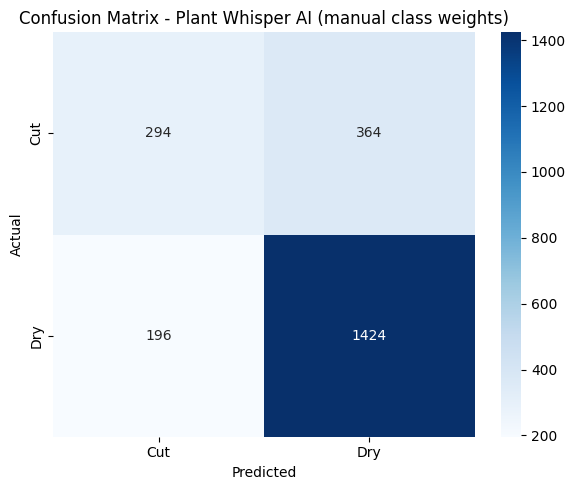

In [24]:
test_generator.reset()
preds = model.predict(test_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

print(cm)
print(classification_report(y_true, y_pred, target_names=class_names))

# Save confusion matrix as an image
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar=True
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Plant Whisper AI (manual class weights)')
plt.tight_layout()

cm_path = "/content/drive/MyDrive/Plant_Whisper_AI/confusion_matrix_manual_weights.png"
try:
    plt.savefig(cm_path, dpi=200)
    print(f"Saved confusion matrix image to {cm_path}")
except OSError:
    local_path = "/content/confusion_matrix_manual_weights.png"
    plt.savefig(local_path, dpi=200)
    print(f"Drive was read-only — saved locally instead to {local_path}")

plt.show()